# `global_priors.json` evaluation

Population-level action prior on **held-out** sessions: union of the eval-side session list and `sessions_theta.txt`. If `sessions_eval.txt` is absent, the eval-side list defaults to `sessions_filter.txt` (see `utils.eval.common`).

Metrics (per head): **NLL**, **multiclass Brier**, **top-1 accuracy**; trained $\beta$ vs heuristic vs train-split marginal.

Cached tensors: `artifacts/global_priors_eval_supervised.npz` via `load_or_build_global_priors_supervised`. Set `FORCE_REBUILD = True` after session file or `POSTFLOP_EQUITY_MC` changes.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

def _repo_root() -> Path:
    p = Path.cwd().resolve()
    for x in (p, *p.parents):
        if (x / "runners" / "common.py").is_file():
            return x
    raise FileNotFoundError("Run from inside the repo (runners/common.py not found).")

REPO = _repo_root()
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import json

import matplotlib.pyplot as plt
import numpy as np

from utils.eval.common import default_global_priors_eval_session_paths
from utils.eval.global_priors_evaluation_helpers import (
    confusion_matrix_counts,
    empirical_marginal,
    global_priors_three_head_predictions,
    load_or_build_global_priors_supervised,
    mean_brier,
    metric_rows_three_heads,
    nll,
    remap_no_bet_labels,
    row_normalise,
    summarize_metric_rows,
    top1_accuracy,
)


In [2]:
train_file, eval_component_file, theta_file = default_global_priors_eval_session_paths(REPO)
print("train:", train_file.relative_to(REPO))
print("eval-side:", eval_component_file.relative_to(REPO))
print("theta:", theta_file.relative_to(REPO))

train: sessions_split/sessions_train.txt
eval-side: sessions_split/sessions_filter.txt
theta: sessions_split/sessions_theta.txt


In [3]:
PRIORS_PATH = REPO / "artifacts" / "global_priors.json"
priors = json.loads(PRIORS_PATH.read_text())
BETA_PRE = np.asarray(priors["preflop"]["beta_preflop"], dtype=float)
BETA_FACING = np.asarray(priors["postflop"]["beta_facing"], dtype=float)
BETA_NO_BET = np.asarray(priors["postflop"]["beta_no_bet"], dtype=float)
print("hands_used:", priors.get("hands_used"))
print("shapes", BETA_PRE.shape, BETA_FACING.shape, BETA_NO_BET.shape)

hands_used: 2725
shapes (3, 28) (3, 30) (2, 30)


In [4]:
POSTFLOP_EQUITY_MC = 30
FORCE_REBUILD = False

bundle = load_or_build_global_priors_supervised(
    REPO,
    train_file=train_file,
    eval_component_file=eval_component_file,
    theta_file=theta_file,
    postflop_equity_mc=POSTFLOP_EQUITY_MC,
    force_rebuild=FORCE_REBUILD,
)
print("from_cache:", bundle.loaded_from_cache)

Supervised cache present but metadata mismatch — rebuilding…
train hands: 2725 | held-out hands: 1556
Wrote artifacts/global_priors_eval_supervised.npz
from_cache: False


In [5]:
X_pre_train, y_pre_train = bundle.X_pre_train, bundle.y_pre_train
Xf_train, yf_train, Xn_train, yn_train = bundle.Xf_train, bundle.yf_train, bundle.Xn_train, bundle.yn_train
X_pre_test, y_pre_test = bundle.X_pre_test, bundle.y_pre_test
Xf_test, yf_test, Xn_test, yn_test = bundle.Xf_test, bundle.yf_test, bundle.Xn_test, bundle.yn_test

y_n_train_local = remap_no_bet_labels(yn_train)
y_n_test_local = remap_no_bet_labels(yn_test)

marg_pre = empirical_marginal(y_pre_train, 3)
marg_facing = empirical_marginal(yf_train, 3)
marg_no_bet = empirical_marginal(y_n_train_local, 2)
print("marginals", np.round(marg_pre, 3), np.round(marg_facing, 3), np.round(marg_no_bet, 3))

marginals [0.714 0.11  0.176] [0.505 0.414 0.081] [0.679 0.321]


In [6]:
preds = global_priors_three_head_predictions(
    beta_pre=BETA_PRE,
    beta_facing=BETA_FACING,
    beta_no_bet=BETA_NO_BET,
    X_pre_test=X_pre_test,
    Xf_test=Xf_test,
    Xn_test=Xn_test,
    marg_pre=marg_pre,
    marg_facing=marg_facing,
    marg_no_bet=marg_no_bet,
)
nll_rows = metric_rows_three_heads(preds, y_pre_test, yf_test, y_n_test_local, metric_fn=nll)
brier_rows = metric_rows_three_heads(preds, y_pre_test, yf_test, y_n_test_local, metric_fn=mean_brier)
top_rows = metric_rows_three_heads(preds, y_pre_test, yf_test, y_n_test_local, metric_fn=top1_accuracy)

print(f"{'head':<8} {'model':<10} {'NLL':>10}")
for h, m, v in nll_rows:
    print(f"{h:<8} {m:<10} {v:>10.4f}")
print(f"{'head':<8} {'model':<10} {'Brier':>10}")
for h, m, v in brier_rows:
    print(f"{h:<8} {m:<10} {v:>10.4f}")
print(f"{'head':<8} {'model':<10} {'top-1':>10}")
for h, m, v in top_rows:
    print(f"{h:<8} {m:<10} {v:>10.4f}")

head     model             NLL
preflop  trained        0.5699
preflop  heuristic      1.0122
preflop  marginal       0.7971
facing   trained        0.7535
facing   heuristic      1.0601
facing   marginal       0.8971
no_bet   trained        0.5606
no_bet   heuristic      1.1992
no_bet   marginal       0.6297
head     model           Brier
preflop  trained        0.3178
preflop  heuristic      0.6419
preflop  marginal       0.4519
facing   trained        0.4440
facing   heuristic      0.6404
facing   marginal       0.5595
no_bet   trained        0.3791
no_bet   heuristic      0.8397
no_bet   marginal       0.4380
head     model           top-1
preflop  trained        0.7421
preflop  heuristic      0.4256
preflop  marginal       0.7103
facing   trained        0.6923
facing   heuristic      0.4438
facing   marginal       0.5126
no_bet   trained        0.7072
no_bet   heuristic      0.3529
no_bet   marginal       0.6762


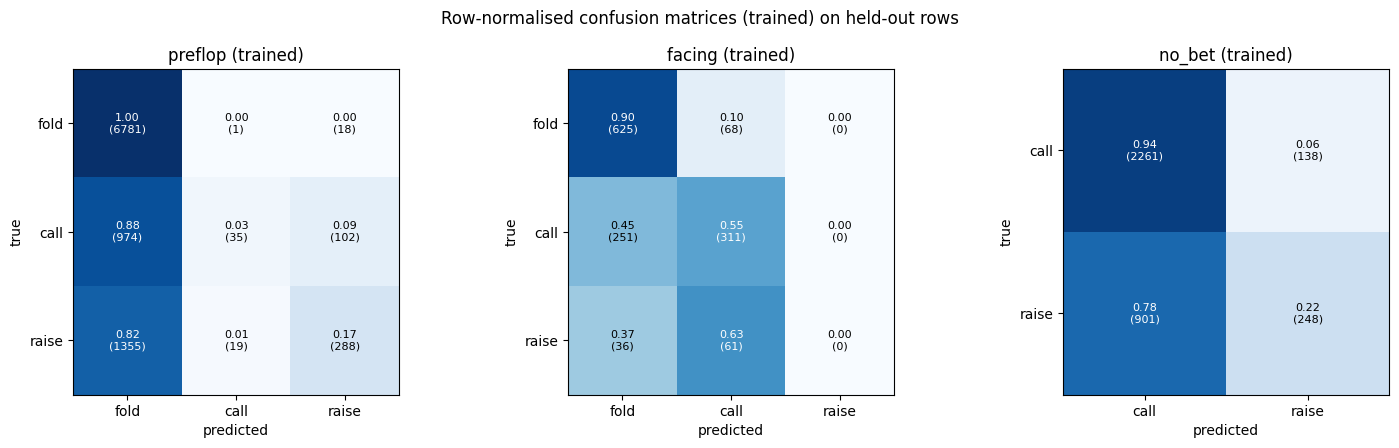

In [ ]:
(P_pre_trained, _, _), (P_f_trained, _, _), (P_n_trained, _, _) = preds

def plot_confusion(M, labels, title, ax):
    Mn = row_normalise(M)
    ax.imshow(Mn, vmin=0.0, vmax=1.0, cmap="Blues")
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    ax.set_xlabel("predicted")
    ax.set_ylabel("true")
    ax.set_title(title)
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            ax.text(
                j, i, f"{Mn[i, j]:.2f}\n({M[i, j]})",
                ha="center", va="center",
                color="white" if Mn[i, j] > 0.5 else "black",
                fontsize=8,
            )

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
cm_pre = confusion_matrix_counts(y_pre_test, P_pre_trained.argmax(axis=1), 3)
cm_f = confusion_matrix_counts(yf_test, P_f_trained.argmax(axis=1), 3)
cm_n = confusion_matrix_counts(y_n_test_local, P_n_trained.argmax(axis=1), 2)
plot_confusion(cm_pre, ["fold", "call", "raise"], "preflop (trained)", axes[0])
plot_confusion(cm_f, ["fold", "call", "raise"], "facing (trained)", axes[1])
plot_confusion(cm_n, ["call", "raise"], "no_bet (trained)", axes[2])
fig.suptitle("Row-normalzsed confusion matrices (trained) on held-out rows")
fig.tight_layout()
plt.show()

In [8]:
summary = summarize_metric_rows(nll_rows, brier_rows, top_rows)
print(f"{'head':<8} {'model':<10} {'NLL':>8} {'Brier':>8} {'top-1':>8}")
for (h, m), vals in summary.items():
    print(f"{h:<8} {m:<10} {vals['NLL']:>8.4f} {vals['Brier']:>8.4f} {vals['top-1']:>8.4f}")

head     model           NLL    Brier    top-1
preflop  trained      0.5699   0.3178   0.7421
preflop  heuristic    1.0122   0.6419   0.4256
preflop  marginal     0.7971   0.4519   0.7103
facing   trained      0.7535   0.4440   0.6923
facing   heuristic    1.0601   0.6404   0.4438
facing   marginal     0.8971   0.5595   0.5126
no_bet   trained      0.5606   0.3791   0.7072
no_bet   heuristic    1.1992   0.8397   0.3529
no_bet   marginal     0.6297   0.4380   0.6762
